# YawDD Yawning Detection

This experiment explores a computer vision classification task using the YawDD dataset.

The goal is to build a pipeline for detecting yawning behavior from extracted video frames and evaluate the performance of deep learning models on this task.

## Environment Setup

The required dependencies are listed in `requirements.txt`.

## Reset Generated Frames, Crops, and Splits

The frame, crops, and splits directories is cleared before each run to avoid mixing outputs from previous preprocessing steps.

In [1]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 85.5 MB/s eta 0:00:29
      --------------------------------------- 0.0/2.4 GB 85.2 MB/s eta 0:00:29
      --------------------------------------- 0.1/2.4 GB 85.7 MB/s eta 0:00:28
     - -------------------------------------- 0.1/2.4 GB 85.6 MB/s eta 0:00:28
     - -------------------------------------- 0.1/2.4 GB 85.7 MB/s eta 0:00:28
     - -------------------------------------- 0.1/2.4 GB 85.8 MB/s eta 0:00:28
     - -------------------------------------- 0.1/2.4 GB 85.0 MB/s eta 0:00:28
     -- ------------------------------------- 0.1/2.4 GB 85.1 MB/s eta 0:00:28
     -- ------------------------------------- 0.2/2.4 GB 85.3 MB/s eta 0:00:27
     -- ------------------------------------- 0.2/2.4 GB 85.4 MB/s eta 0:00:27
  

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
open-webui 0.9.5 requires pillow==12.1.1, but you have pillow 12.3.0 which is incompatible.

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: C:\Users\laith\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [ ]:
import os
import shutil
from pathlib import Path


frames_dir = Path(r"C:\Users\laith\Desktop\UniAssignments\CV\YawDD\data\output\frames")

for item in frames_dir.iterdir():
    if item.is_dir():
        shutil.rmtree(item)
    else:
        item.unlink()

print(f"Cleared: {frames_dir}")

In [ ]:
frames_dir = Path(r"C:\Users\laith\Desktop\UniAssignments\CV\YawDD\data\output\crops")

for item in frames_dir.iterdir():
    if item.is_dir():
        shutil.rmtree(item)
    else:
        item.unlink()

print(f"Cleared: {frames_dir}")

In [ ]:
frames_dir = Path(r"C:\Users\laith\Desktop\UniAssignments\CV\YawDD\data\output\splits")

for item in frames_dir.iterdir():
    if item.is_dir():
        shutil.rmtree(item)
    else:
        item.unlink()

print(f"Cleared: {frames_dir}")

In [2]:
import os
import math

import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

## Project Paths

The experiment uses a structured directory layout for storing raw data, extracted frames, processed crops, and generated metadata files.

In [3]:
from pathlib import Path


# Dataset directory (read-only)
DATASET_ROOT = Path("data/raw")

# Experiment outputs
OUTPUT_ROOT = Path("data/output")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)


# Generated files
VIDEOS_INFO_PATH = OUTPUT_ROOT / "videos_info.csv"
FRAMES_ROOT = OUTPUT_ROOT / "frames"
FRAMES_INFO_PATH = OUTPUT_ROOT / "frames_info.csv"

CROPS_ROOT = OUTPUT_ROOT / "crops"
CROPS_INFO_PATH = OUTPUT_ROOT / "crops_labeled.csv"

SPLIT_DIR = OUTPUT_ROOT / "splits"


for directory in [FRAMES_ROOT, CROPS_ROOT, SPLIT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def safe_imread(path):
    """
    Load an image and raise an error if the file cannot be read.
    """
    image = cv2.imread(str(path))

    if image is None:
        raise FileNotFoundError(f"Unable to read image: {path}")

    return image

## Dataset Indexing

The raw dataset is scanned to create a metadata file containing video paths, labels, and subject identifiers.

The subject identifier is used later during dataset splitting to prevent frames extracted from the same video from appearing in both training and validation sets.

In [ ]:
import pandas as pd
from pathlib import Path


video_rows = []

print(f"Scanning dataset: {DATASET_ROOT}")

for video_path in Path(DATASET_ROOT).rglob("*"):
    if video_path.suffix.lower() in {".mp4", ".avi", ".mov", ".mkv"}:

        group = video_path.parent.name
        video_id = video_path.stem

        # Use video-level identifiers to prevent frame-level data leakage
        subject = video_id

        video_rows.append(
            {
                "video_path": str(video_path),
                "video_name": video_path.name,
                "subject": subject,
                "group": group,
            }
        )


videos_df = pd.DataFrame(video_rows)

videos_df.to_csv(VIDEOS_INFO_PATH, index=False)

print(f"Saved {len(videos_df)} videos to {VIDEOS_INFO_PATH}")
print(videos_df.head())

print(f"\nUnique subjects: {videos_df['subject'].nunique()}")
print(f"Unique groups: {videos_df['group'].nunique()}")

## Frame Extraction

The video files are converted into individual frames before training.

Frames are sampled at 10 FPS to reduce redundancy while preserving enough temporal information for the yawning detection task. Metadata for each extracted frame is stored to maintain the connection between frames and their original videos.

In [ ]:
from pathlib import Path


FRAMES_OUTPUT_DIR = FRAMES_ROOT / "frames"

FRAMES_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

frames_info = []
TARGET_FPS = 10


for _, row in tqdm(videos_df.iterrows(), total=len(videos_df)):

    video_path = row["video_path"]
    subject = row["subject"]
    video_name = row["video_name"]

    video_id = Path(video_name).stem
    save_dir = FRAMES_OUTPUT_DIR / f"{subject}_{video_id}"

    save_dir.mkdir(parents=True, exist_ok=True)


    cap = cv2.VideoCapture(video_path)

    if not cap.isOpened():
        print(f"Could not open video: {video_path}")
        continue


    original_fps = cap.get(cv2.CAP_PROP_FPS) or TARGET_FPS
    frame_step = max(1, round(original_fps / TARGET_FPS))

    frame_index = 0
    saved_frames = 0


    while True:
        ret, frame = cap.read()

        if not ret:
            break


        if frame_index % frame_step == 0:

            frame_path = save_dir / f"frame_{saved_frames:05d}.jpg"

            cv2.imwrite(str(frame_path), frame)

            frames_info.append(
                {
                    "frame_path": str(frame_path),
                    "subject": subject,
                    "video_name": video_name,
                    "frame_index": saved_frames,
                }
            )

            saved_frames += 1


        frame_index += 1


    cap.release()


frames_df = pd.DataFrame(frames_info)

frames_df.to_csv(FRAMES_INFO_PATH, index=False)

print(f"Saved {len(frames_df)} frames to {FRAMES_INFO_PATH}")

frames_df.head()

## Automatic Frame Labeling

Frame-level labels are generated using facial landmarks extracted with MediaPipe FaceMesh.

The Mouth Aspect Ratio (MAR) is used as a simple indicator of mouth opening. Frames with sustained high MAR values are labeled as yawning frames, while the remaining frames are treated as non-yawning.

Temporal smoothing is applied to reduce noise from individual frame detections.

In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import mediapipe as mp
from tqdm import tqdm


FRAMES_DIR = FRAMES_ROOT / "frames"


mp_face_mesh = mp.solutions.face_mesh


# MediaPipe mouth landmarks
LIP_LEFT = 61
LIP_RIGHT = 291
LIP_TOP = 13
LIP_BOTTOM = 14


def calculate_mar(landmarks, width, height):
    """
    Calculate Mouth Aspect Ratio (MAR) from facial landmarks.
    """

    def point(index):
        return np.array(
            [
                landmarks[index].x * width,
                landmarks[index].y * height,
            ],
            dtype=np.float32,
        )

    left = point(LIP_LEFT)
    right = point(LIP_RIGHT)
    top = point(LIP_TOP)
    bottom = point(LIP_BOTTOM)

    mouth_width = np.linalg.norm(right - left) + 1e-6
    mouth_height = np.linalg.norm(bottom - top)

    return float(mouth_height / mouth_width)

In [ ]:
def calculate_mar(landmarks, width, height):
    """
    Calculate Mouth Aspect Ratio (MAR) using facial landmarks.
    """

    def point(index):
        return np.array(
            [
                landmarks[index].x * width,
                landmarks[index].y * height,
            ],
            dtype=np.float32
        )

    left = point(LIP_LEFT)
    right = point(LIP_RIGHT)
    top = point(LIP_TOP)
    bottom = point(LIP_BOTTOM)

    mouth_width = np.linalg.norm(right - left) + 1e-6
    mouth_height = np.linalg.norm(bottom - top)

    return float(mouth_height / mouth_width)

In [ ]:
def smooth_signal(values, kernel_size=7):
    values = values.copy()

    if np.all(np.isnan(values)):
        return values

    values[np.isnan(values)] = np.nanmean(values)

    kernel = np.ones(kernel_size) / kernel_size

    return np.convolve(values, kernel, mode="same")

In [ ]:
def detect_yawning_frames(
    mar_values,
    threshold=0.35,
    min_duration=8
):
    """
    Detect yawning events based on sustained MAR values.
    """

    above_threshold = mar_values > threshold
    labels = np.zeros_like(above_threshold, dtype=bool)

    start = None

    for index, value in enumerate(above_threshold):

        if value and start is None:
            start = index

        if (not value or index == len(above_threshold)-1) and start is not None:

            end = index if not value else index + 1

            if end - start >= min_duration:
                labels[start:end] = True

            start = None
    return labels

In [ ]:
def compute_frame_mar(image, face_mesh):

    height, width = image.shape[:2]

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    result = face_mesh.process(rgb)

    if not result.multi_face_landmarks:
        return np.nan

    landmarks = result.multi_face_landmarks[0].landmark

    return calculate_mar(landmarks, width, height)

In [ ]:
all_rows = []

video_folders = sorted(
    [p for p in FRAMES_DIR.iterdir() if p.is_dir()]
)

with mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
) as face_mesh:

    for video_folder in tqdm(video_folders, desc="Labeling frames"):

        frames = sorted(
            [
                p for p in video_folder.iterdir()
                if p.suffix.lower() in {".jpg", ".png"}
            ]
        )

        mar_values = []
        frame_paths = []

        for frame_path in frames:

            image = cv2.imread(str(frame_path))

            if image is None:
                mar_values.append(np.nan)
            else:
                mar_values.append(
                    compute_frame_mar(image, face_mesh)
                )

            frame_paths.append(frame_path)


        mar_values = np.array(mar_values, dtype=np.float32)

        smoothed_mar = smooth_signal(
            mar_values,
            kernel_size=7
        )

        smoothed_mar = np.nan_to_num(
            smoothed_mar,
            nan=0.0
        )


        yawn_mask = detect_yawning_frames(
            smoothed_mar,
            threshold=0.35,
            min_duration=8
        )


        for path, mar_value, is_yawn in zip(
            frame_paths,
            smoothed_mar,
            yawn_mask
        ):

            all_rows.append(
                {
                    "video_id": video_folder.name,
                    "frame_path": str(path),
                    "mar": float(mar_value),
                    "label": int(is_yawn),
                }
            )


labels_df = pd.DataFrame(all_rows)

LABELS_CSV = OUTPUT_ROOT / "frames_labels.csv"

labels_df.to_csv(
    LABELS_CSV,
    index=False
)

print(f"Saved frame labels to: {LABELS_CSV}")

print("\nLabel distribution:")
print(labels_df["label"].value_counts())

## Dataset Construction

The detected facial regions are used to create the final training dataset.

Instead of training on complete frames, mouth regions are extracted to focus the model on the visual features related to yawning behavior. The generated crops are stored together with their labels and metadata for later training.

In [ ]:
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
from pathlib import Path
from tqdm import tqdm


# Paths from previous preprocessing steps
FRAMES_INFO_PATH = FRAMES_INFO_PATH
CROPS_ROOT = CROPS_ROOT
CROPS_INFO_PATH = CROPS_INFO_PATH

CROPS_ROOT.mkdir(parents=True, exist_ok=True)


frames_df = pd.read_csv(FRAMES_INFO_PATH)

LABELS_CSV = OUTPUT_ROOT / "frames_labels.csv"
labels_df = pd.read_csv(LABELS_CSV)

## Merge Frame Labels

The frame metadata and generated labels are combined to create a single dataframe containing all information required for crop extraction.

In [ ]:
def normalize_path(path):
    path = str(path).replace("\\", "/")

    if not path.startswith("/"):
        path = str(Path(path).resolve())

    return path


frames_df["frame_path"] = frames_df["frame_path"].apply(normalize_path)
labels_df["frame_path"] = labels_df["frame_path"].apply(normalize_path)


frames_df = frames_df.merge(
    labels_df[["frame_path", "label"]],
    on="frame_path",
    how="left"
)


missing_labels = frames_df["label"].isna().sum()

print(f"Frames loaded: {len(frames_df)}")
print(f"Missing labels: {missing_labels}")

# Remove frames without generated labels
frames_df = frames_df.dropna(subset=["label"])

frames_df["label"] = frames_df["label"].astype(int)

print(f"Frames remaining after removing missing labels: {len(frames_df)}")

print("\nLabel distribution:")
print(frames_df["label"].value_counts())

print("\nLabel distribution:")
print(frames_df["label"].value_counts())

In [ ]:
print(labels_df.columns)
print(labels_df.head())

## Facial Landmark Extraction

MediaPipe FaceMesh is used to locate facial landmarks and extract the mouth region from each frame.

In [ ]:
mp_face_mesh = mp.solutions.face_mesh

face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)


LIP_LEFT = 61
LIP_RIGHT = 291
LIP_TOP = 13
LIP_BOTTOM = 14

In [ ]:
def extract_mouth_crop(image, landmarks):
    """
    Extract the mouth region using MediaPipe facial landmarks.
    """

    height, width = image.shape[:2]


    def point(index):
        return (
            int(landmarks[index].x * width),
            int(landmarks[index].y * height)
        )


    left_x, left_y = point(LIP_LEFT)
    right_x, right_y = point(LIP_RIGHT)

    top_x, top_y = point(LIP_TOP)
    bottom_x, bottom_y = point(LIP_BOTTOM)


    x_min = max(0, min(left_x, right_x) - 10)
    x_max = min(width, max(left_x, right_x) + 10)

    y_min = max(0, min(top_y, bottom_y) - 10)
    y_max = min(height, max(top_y, bottom_y) + 10)


    if x_max <= x_min or y_max <= y_min:
        return None


    return image[y_min:y_max, x_min:x_max]

## Generate Mouth Crops

Each labeled frame is processed to extract the mouth region. The resulting crops are saved and linked with their original metadata and labels.

In [ ]:
crop_rows = []


for _, row in tqdm(
    frames_df.iterrows(),
    total=len(frames_df),
    desc="Extracting mouth crops"
):

    frame_path = row["frame_path"]

    image = cv2.imread(frame_path)

    if image is None:
        continue


    rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    result = face_mesh.process(rgb)


    if not result.multi_face_landmarks:
        continue


    landmarks = result.multi_face_landmarks[0].landmark

    mouth_crop = extract_mouth_crop(
        image,
        landmarks
    )


    if mouth_crop is None or mouth_crop.size == 0:
        continue


    subject_dir = CROPS_ROOT / row["subject"]

    subject_dir.mkdir(
        parents=True,
        exist_ok=True
    )


    crop_name = (
        f"{Path(row['video_name']).stem}_"
        f"{int(row['frame_index']):05d}.jpg"
    )


    crop_path = subject_dir / crop_name


    cv2.imwrite(
        str(crop_path),
        mouth_crop
    )


    crop_rows.append(
        {
            "crop_path": str(crop_path),
            "subject": row["subject"],
            "video_name": row["video_name"],
            "frame_index": row["frame_index"],
            "label": int(row["label"])
        }
    )

In [ ]:
crops_df = pd.DataFrame(crop_rows)

crops_df.to_csv(
    CROPS_INFO_PATH,
    index=False
)


print(f"Total crops saved: {len(crops_df)}")
print(f"Saved metadata to: {CROPS_INFO_PATH}")

crops_df.head()

In [ ]:
print(f"Total crops: {len(crops_df)}")
print("\nLabel distribution:")
print(crops_df["label"].value_counts())

crops_df = pd.read_csv(CROPS_INFO_PATH)

duplicate_labels = (
    crops_df
    .groupby(["subject", "video_name", "frame_index"])["label"]
    .nunique()
)

conflicting_frames = (duplicate_labels > 1).sum()

print(f"Frames with conflicting labels: {conflicting_frames}")

## Dataset Split

The dataset is split at the subject level to prevent data leakage between training, validation, and test sets.

Since multiple frames are extracted from the same video, randomly splitting individual images could result in nearly identical samples appearing in different splits. Splitting by subject ensures a more realistic evaluation.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path


crops_df = pd.read_csv(CROPS_INFO_PATH)


subjects = crops_df["subject"].unique()

rng = np.random.default_rng(42)
rng.shuffle(subjects)


num_subjects = len(subjects)

train_size = int(0.7 * num_subjects)
val_size = int(0.15 * num_subjects)


train_subjects = subjects[:train_size]

val_subjects = subjects[
    train_size:train_size + val_size
]

test_subjects = subjects[
    train_size + val_size:
]


train_df = crops_df[
    crops_df["subject"].isin(train_subjects)
].reset_index(drop=True)


val_df = crops_df[
    crops_df["subject"].isin(val_subjects)
].reset_index(drop=True)


test_df = crops_df[
    crops_df["subject"].isin(test_subjects)
].reset_index(drop=True)


SPLIT_DIR = OUTPUT_ROOT / "splits"

SPLIT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


train_df.to_csv(
    SPLIT_DIR / "train.csv",
    index=False
)

val_df.to_csv(
    SPLIT_DIR / "val.csv",
    index=False
)

test_df.to_csv(
    SPLIT_DIR / "test.csv",
    index=False
)


print(f"Total subjects: {num_subjects}")

print(
    f"Train / Val / Test subjects: "
    f"{len(train_subjects)} / "
    f"{len(val_subjects)} / "
    f"{len(test_subjects)}"
)


print(
    f"Samples: "
    f"train={len(train_df)}, "
    f"val={len(val_df)}, "
    f"test={len(test_df)}"
)

In [ ]:
assert len(set(train_subjects) & set(val_subjects)) == 0
assert len(set(train_subjects) & set(test_subjects)) == 0
assert len(set(val_subjects) & set(test_subjects)) == 0

print("No subject overlap between splits.")

## Dataset Pipeline

A PyTorch dataset is created to load the extracted mouth crops and corresponding labels.

Images are resized, converted into tensors, and normalized before being passed to the model. The dataset is split into training, validation, and test loaders using the subject-level splits created previously.

In [6]:
import cv2
import torch
import pandas as pd

from torch.utils.data import Dataset


class MouthDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.data = pd.read_csv(csv_path)
        self.transform = transform

        self.mean = torch.tensor(
            [0.485, 0.456, 0.406],
            dtype=torch.float32
        ).view(3, 1, 1)

        self.std = torch.tensor(
            [0.229, 0.224, 0.225],
            dtype=torch.float32
        ).view(3, 1, 1)


    def __len__(self):
        return len(self.data)


    def __getitem__(self, idx):

        row = self.data.iloc[idx]

        image_path = row["crop_path"]

        image = cv2.imread(image_path)

        if image is None:
            raise FileNotFoundError(
                f"Unable to read image: {image_path}"
            )


        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = cv2.resize(
            image,
            (224, 224),
            interpolation=cv2.INTER_AREA
        )


        image = (
            torch.from_numpy(image)
            .permute(2, 0, 1)
            .contiguous()
            .float()
            .div(255.0)
        )


        image = (image - self.mean) / self.std


        label = torch.tensor(
            int(row["label"]),
            dtype=torch.long
        )


        if self.transform:
            image = self.transform(image)


        return image, label

## DataLoaders

The datasets are wrapped in PyTorch DataLoaders to enable mini-batch training and efficient data loading.

In [7]:
from torch.utils.data import DataLoader


BATCH_SIZE = 32
NUM_WORKERS = 0

PIN_MEMORY = torch.cuda.is_available()


loader_config = {
    "batch_size": 32,
    "num_workers": 0,
    "pin_memory": torch.cuda.is_available(),
}


if NUM_WORKERS > 0:
    loader_config.update(
        {
            "persistent_workers": True,
            "prefetch_factor": 2,
        }
    )


train_loader = DataLoader(
    MouthDataset(SPLIT_DIR / "train.csv"),
    shuffle=True,
    **loader_config
)


val_loader = DataLoader(
    MouthDataset(SPLIT_DIR / "val.csv"),
    shuffle=False,
    **loader_config
)


test_loader = DataLoader(
    MouthDataset(SPLIT_DIR / "test.csv"),
    shuffle=False,
    **loader_config
)

In [8]:
images, labels = next(iter(train_loader))


print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

print(
    "Label distribution in batch:",
    torch.bincount(labels)
)

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Label distribution in batch: tensor([31,  1])


## Model Training

A convolutional neural network is trained on the extracted mouth crops to classify frames as yawning or non-yawning.

The training pipeline includes model definition, optimization, evaluation metrics, and training monitoring.

In [9]:
import time

import torch
import torch.nn as nn
from torch.utils.data import WeightedRandomSampler

import torchvision
from torchvision import transforms

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

## Training Utilities

Helper functions used throughout training and evaluation are defined here, including reproducibility settings, path handling, and result visualization.

In [10]:
import random
import numpy as np
import torch
import matplotlib.pyplot as plt


def set_seed(seed=42):
    """
    Set random seeds for reproducible experiments.
    """

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



def normalize_path(path):
    """
    Convert paths to a consistent format across operating systems.
    """

    return str(path).replace("\\", "/")



def plot_confusion_matrix(cm, class_names, title, save_path=None):

    plt.figure(figsize=(7, 6))

    plt.imshow(
        cm,
        interpolation="nearest"
    )

    plt.title(title)

    plt.colorbar()


    ticks = np.arange(len(class_names))

    plt.xticks(
        ticks,
        class_names,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        ticks,
        class_names
    )


    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")

    plt.tight_layout()


    if save_path:
        plt.savefig(
            save_path,
            dpi=200,
            bbox_inches="tight"
        )


    plt.show()

In [11]:
import random
import numpy as np
import torch


def set_seed(seed=42):
    """
    Set random seeds for reproducible experiments.
    """

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

## Experiment Configuration

Training parameters, hardware configuration, and output directories are defined before model training.

A fixed random seed is used to improve reproducibility across experiments.

In [12]:
import os
import torch


SEED = 42
set_seed(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if device.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# Training parameters

IMG_SIZE = 224

BATCH_SIZE = 64

EPOCHS = 30

LEARNING_RATE = 3e-4

WEIGHT_DECAY = 1e-4


MODEL_NAME = "resnet18"


# Dataset split ratios

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15
TEST_FRAC = 0.15


# Output directories

OUTPUT_DIR = OUTPUT_ROOT / "training"

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

PLOTS_DIR = OUTPUT_DIR / "plots"


CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PLOTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# DataLoader settings

PIN_MEMORY = device.type == "cuda"

NUM_WORKERS = 0

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU


In [13]:
print(device)

cuda


In [14]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


## Training Data Validation

The generated split files are loaded and checked before training.

The checks ensure that required metadata fields are available and that labels are correctly formatted.

In [15]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df = pd.read_csv(SPLIT_DIR / "val.csv")
test_df = pd.read_csv(SPLIT_DIR / "test.csv")


required_columns = {
    "crop_path",
    "subject",
    "label"
}


for name, df in {
    "train": train_df,
    "validation": val_df,
    "test": test_df
}.items():

    missing = required_columns - set(df.columns)

    if missing:
        raise ValueError(
            f"{name} split is missing columns: {missing}"
        )


    df["crop_path"] = (
        df["crop_path"]
        .astype(str)
        .apply(normalize_path)
    )

    df["subject"] = df["subject"].astype(str)

    df["label"] = df["label"].astype(int)


print("Training samples:", len(train_df))
print("Validation samples:", len(val_df))
print("Test samples:", len(test_df))

Training samples: 64367
Validation samples: 15635
Test samples: 15236


## Image Path Validation

Before training, the dataset is checked to ensure that all image paths referenced in the metadata files exist.

Missing files are removed to prevent runtime errors during data loading.

In [16]:
file_exists = df["crop_path"].apply(os.path.exists)

missing_files = (~file_exists).sum()

print(f"Total samples: {len(df)}")
print(f"Missing image files: {missing_files}")


if missing_files > 0:
    print("Removing samples with unavailable image files.")

    df = (
        df[file_exists]
        .reset_index(drop=True)
    )


print(f"Samples used: {len(df)}")

print("\nLabel distribution:")
print(
    df["label"]
    .value_counts()
    .sort_index()
)

Total samples: 15236
Missing image files: 0
Samples used: 15236

Label distribution:
label
0    14218
1     1018
Name: count, dtype: int64


## Dataset and Transform Pipeline

A PyTorch dataset is created to load the extracted mouth crops.

Training images use augmentation to improve generalization, while validation and test images use only resizing and normalization.

In [17]:
from PIL import Image


class CropDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform


    def __len__(self):
        return len(self.df)


    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = row["crop_path"]

        image = cv2.imread(image_path)

        if image is None:
            raise FileNotFoundError(
                f"Unable to read image: {image_path}"
            )


        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        image = Image.fromarray(image)


        if self.transform:
            image = self.transform(image)


        label = int(row["label"])

        return image, label

In [18]:
train_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),

        transforms.RandomRotation(10),

        transforms.RandomHorizontalFlip(
            p=0.5
        ),

        transforms.RandomApply(
            [
                transforms.ColorJitter(
                    brightness=0.2,
                    contrast=0.2
                )
            ],
            p=0.7
        ),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ]
)


eval_transforms = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),

        transforms.ToTensor(),

        transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ),
    ]
)

In [19]:
train_dataset = CropDataset(
    train_df,
    transform=train_transforms
)

val_dataset = CropDataset(
    val_df,
    transform=eval_transforms
)

test_dataset = CropDataset(
    test_df,
    transform=eval_transforms
)

In [20]:
from torch.utils.data import WeightedRandomSampler, DataLoader


# Calculate class frequencies
train_labels = train_df["label"].values

class_counts = np.bincount(train_labels)

class_weights = 1.0 / np.maximum(class_counts, 1)

sample_weights = class_weights[train_labels]


sampler = WeightedRandomSampler(
    weights=torch.tensor(
        sample_weights,
        dtype=torch.double
    ),
    num_samples=len(sample_weights),
    replacement=True
)


NUM_WORKERS = 0

PIN_MEMORY = device.type == "cuda"


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)


criterion = nn.CrossEntropyLoss(
    label_smoothing=0.05
).to(device)

In [21]:
print(train_df["label"].value_counts())

label
0    60291
1     4076
Name: count, dtype: int64


## Model Architecture

A pretrained convolutional neural network is fine-tuned for binary yawning classification.

The final classification layer is replaced to match the number of dataset classes.

In [25]:
import torchvision
import torch.nn as nn


def build_model(name, num_classes):

    name = name.lower().strip()


    if name == "resnet18":

        model = torchvision.models.resnet18(
            weights=torchvision.models.ResNet18_Weights.IMAGENET1K_V1
        )

        model.fc = nn.Linear(
            model.fc.in_features,
            num_classes
        )


    elif name == "efficientnet_b0":

        model = torchvision.models.efficientnet_b0(
            weights=torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1
        )

        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            num_classes
        )


    elif name == "mobilenet_v3_small":

        model = torchvision.models.mobilenet_v3_small(
            weights=torchvision.models.MobileNet_V3_Small_Weights.IMAGENET1K_V1
        )

        model.classifier[3] = nn.Linear(
            model.classifier[3].in_features,
            num_classes
        )


    else:
        raise ValueError(
            f"Unsupported model: {name}"
        )


    return model

In [26]:
NUM_CLASSES = train_df["label"].nunique()


model = build_model(
    MODEL_NAME,
    NUM_CLASSES
).to(device)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1
)


print(
    f"Model: {MODEL_NAME}"
)

print(
    f"Classes: {NUM_CLASSES}"
)

Model: resnet18
Classes: 2


In [ ]:
NUM_CLASSES = train_df["label"].nunique()


model = build_model(
    MODEL_NAME,
    NUM_CLASSES
).to(device)


optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LEARNING_RATE,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1
)


print(
    f"Model: {MODEL_NAME}"
)

print(
    f"Classes: {NUM_CLASSES}"
)

Model: resnet18
Classes: 2


In [28]:
torch.save(
    model.state_dict(),
    "resnet18_initial.pth"
)

## Learning Rate Experiment

A small learning rate search is performed before final training.

Each candidate learning rate is evaluated after one training epoch using validation performance.

In [34]:
import copy
import time


def train_lr_trial(
    model,
    train_loader,
    criterion,
    optimizer,
    device
):

    model.train()

    total_loss = 0
    total_samples = 0


    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)


        optimizer.zero_grad()


        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )


        loss.backward()

        optimizer.step()


        batch_size = images.size(0)

        total_loss += loss.item() * batch_size
        total_samples += batch_size


    return total_loss / total_samples



def run_lr_experiment(
    model,
    train_loader,
    val_loader,
    criterion,
    device,
    learning_rates
):

    initial_weights = copy.deepcopy(
        model.state_dict()
    )

    results = []


    for lr in learning_rates:

        print("\n" + "-" * 40)
        print(f"Testing learning rate: {lr}")


        model.load_state_dict(
            initial_weights
        )


        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=lr,
            weight_decay=WEIGHT_DECAY
        )


        start = time.time()


        train_loss = train_lr_trial(
            model,
            train_loader,
            criterion,
            optimizer,
            device
        )


        val_accuracy, val_f1 = evaluate(
            model,
            val_loader,
            device
        )


        elapsed = time.time() - start


        results.append(
            {
                "learning_rate": lr,
                "train_loss": train_loss,
                "val_accuracy": val_accuracy,
                "val_f1": val_f1,
                "time_seconds": elapsed
            }
        )


        print(
            f"Loss: {train_loss:.4f}"
        )

        print(
            f"Validation accuracy: {val_accuracy:.4f}"
        )

        print(
            f"Validation F1: {val_f1:.4f}"
        )


    return results

In [35]:
learning_rates = [
    1e-4,
    3e-4,
    1e-3
]


lr_results = run_lr_experiment(
    model,
    train_loader,
    val_loader,
    criterion,
    device,
    learning_rates
)


pd.DataFrame(lr_results)


----------------------------------------
Testing learning rate: 0.0001
Loss: 0.1416
Validation accuracy: 0.9784
Validation F1: 0.9247

----------------------------------------
Testing learning rate: 0.0003
Loss: 0.1578
Validation accuracy: 0.9615
Validation F1: 0.8848

----------------------------------------
Testing learning rate: 0.001
Loss: 0.1786
Validation accuracy: 0.9685
Validation F1: 0.8983


,learning_rate,train_loss,val_accuracy,val_f1,time_seconds
0,0.0001,0.141586,0.978446,0.924731,697.839995
1,0.0003,0.157844,0.961497,0.884812,558.729646
2,0.0010,0.178629,0.968468,0.898333,551.314764


## Training and Evaluation

The model is trained using mixed-precision when CUDA is available. After each epoch, validation performance is measured using accuracy, precision, recall, and macro F1 score.

Macro F1 is reported alongside accuracy because the dataset is class-imbalanced.

In [36]:
scaler = torch.cuda.amp.GradScaler(
    enabled=(device.type == "cuda")
)


def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scheduler,
    device
):
    model.train()

    running_loss = 0.0
    total_samples = 0

    progress = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, labels in progress:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.cuda.amp.autocast(
            enabled=(device.type == "cuda")
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()


        if scheduler is not None:
            scheduler.step()


        batch_size = images.size(0)

        running_loss += loss.item() * batch_size
        total_samples += batch_size


        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )


    return running_loss / total_samples

C:\Users\laith\AppData\Local\Temp\ipykernel_3520\1313398015.py:1: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(


In [37]:
@torch.no_grad()
def evaluate(
    model,
    loader,
    device
):
    model.eval()

    all_labels = []
    all_predictions = []


    for images, labels in tqdm(
        loader,
        desc="Evaluating",
        leave=False
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        outputs = model(images)

        predictions = outputs.argmax(dim=1)


        all_labels.append(
            labels.cpu().numpy()
        )

        all_predictions.append(
            predictions.cpu().numpy()
        )


    all_labels = np.concatenate(all_labels)
    all_predictions = np.concatenate(all_predictions)


    accuracy = accuracy_score(
        all_labels,
        all_predictions
    )


    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            all_labels,
            all_predictions,
            average="macro",
            zero_division=0
        )
    )


    return (
        accuracy,
        precision,
        recall,
        f1,
        all_labels,
        all_predictions
    )

## Final Training

The model is trained using the selected configuration and monitored on the validation set after each epoch.

The checkpoint with the highest validation macro F1 score is saved. Early stopping is used to stop training when validation performance no longer improves.

In [38]:
best_val_f1 = -1.0
epochs_no_improve = 0

PATIENCE = 3
MIN_DELTA = 1e-4

history = []

best_checkpoint_path = (
    CHECKPOINT_DIR / f"{MODEL_NAME}_best.pt"
)


for epoch in range(1, EPOCHS + 1):

    start_time = time.time()


    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scheduler,
        device
    )


    (
        val_accuracy,
        val_precision,
        val_recall,
        val_f1,
        _,
        _
    ) = evaluate(
        model,
        val_loader,
        device
    )


    elapsed = time.time() - start_time


    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"loss={train_loss:.4f} | "
        f"val_acc={val_accuracy:.4f} | "
        f"val_macro_f1={val_f1:.4f} | "
        f"time={elapsed:.1f}s"
    )


    history.append(
        {
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_accuracy": float(val_accuracy),
            "val_macro_precision": float(val_precision),
            "val_macro_recall": float(val_recall),
            "val_macro_f1": float(val_f1),
            "learning_rate": float(
                optimizer.param_groups[0]["lr"]
            ),
            "time_seconds": float(elapsed),
        }
    )


    if val_f1 > best_val_f1 + MIN_DELTA:

        best_val_f1 = val_f1
        epochs_no_improve = 0


        torch.save(
            {
                "model_name": MODEL_NAME,
                "model_state_dict": model.state_dict(),
                "num_classes": NUM_CLASSES,
                "best_val_macro_f1": float(best_val_f1),
                "epoch": epoch,
                "config": {
                    "image_size": IMG_SIZE,
                    "batch_size": BATCH_SIZE,
                    "epochs": EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "weight_decay": WEIGHT_DECAY,
                    "seed": SEED,
                    "patience": PATIENCE,
                    "min_delta": MIN_DELTA,
                },
            },
            best_checkpoint_path
        )


        print(
            f"Saved best checkpoint: "
            f"{best_checkpoint_path}"
        )


    else:

        epochs_no_improve += 1

        print(
            f"No improvement: "
            f"{epochs_no_improve}/{PATIENCE}"
        )


        if epochs_no_improve >= PATIENCE:

            print(
                f"Early stopping at epoch {epoch}. "
                f"Best validation macro F1: "
                f"{best_val_f1:.4f}"
            )

            break

Training:   0%|          | 0/1006 [00:00<?, ?it/s]

C:\Users\laith\AppData\Local\Temp\ipykernel_3520\1313398015.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Evaluating:   0%|          | 0/245 [00:00<?, ?it/s]

Epoch 01/30 | loss=0.1538 | val_acc=0.9731 | val_macro_f1=0.9127 | time=423.5s
Saved best checkpoint: data\output\training\checkpoints\resnet18_best.pt


Training:   0%|          | 0/1006 [00:00<?, ?it/s]

...

Epoch 04/30 | loss=0.1372 | val_acc=0.9728 | val_macro_f1=0.9114 | time=1089.7s
No improvement: 2/3


Training:   0%|          | 0/1006 [00:00<?, ?it/s]

C:\Users\laith\AppData\Local\Temp\ipykernel_3520\1313398015.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(


Evaluating:   0%|          | 0/245 [00:00<?, ?it/s]

Epoch 05/30 | loss=0.1340 | val_acc=0.9722 | val_macro_f1=0.9082 | time=388.3s
No improvement: 3/3
Early stopping at epoch 5. Best validation macro F1: 0.9172


In [39]:
history_df = pd.DataFrame(history)

history_path = (
    OUTPUT_DIR / f"history_{MODEL_NAME}.csv"
)

history_df.to_csv(
    history_path,
    index=False
)


print(f"Saved training history: {history_path}")
print(f"Best checkpoint: {best_checkpoint_path}")
print(f"Best validation macro F1: {best_val_f1:.4f}")

Saved training history: data\output\training\history_resnet18.csv
Best checkpoint: data\output\training\checkpoints\resnet18_best.pt
Best validation macro F1: 0.9172


## Test Evaluation

After training is complete, the checkpoint with the best validation macro F1 score is loaded and evaluated once on the held-out test set.

Accuracy, macro precision, macro recall, macro F1, a classification report, and a confusion matrix are reported.

In [40]:
checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model.eval()


(
    test_accuracy,
    test_precision,
    test_recall,
    test_f1,
    y_true,
    y_pred
) = evaluate(
    model,
    test_loader,
    device
)


print("\n=== Test Results ===")
print(f"Accuracy:        {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1:        {test_f1:.4f}")

C:\Users\laith\AppData\Local\Temp\ipykernel_3520\312573942.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


Evaluating:   0%|          | 0/239 [00:00<?, ?it/s]


=== Test Results ===
Accuracy:        0.9902
Macro Precision: 0.9518
Macro Recall:    0.9720
Macro F1:        0.9616


In [41]:
print("\nClassification Report:")

print(
    classification_report(
        y_true,
        y_pred,
        zero_division=0
    )
)


Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     14218
           1       0.91      0.95      0.93      1018

    accuracy                           0.99     15236
   macro avg       0.95      0.97      0.96     15236
weighted avg       0.99      0.99      0.99     15236



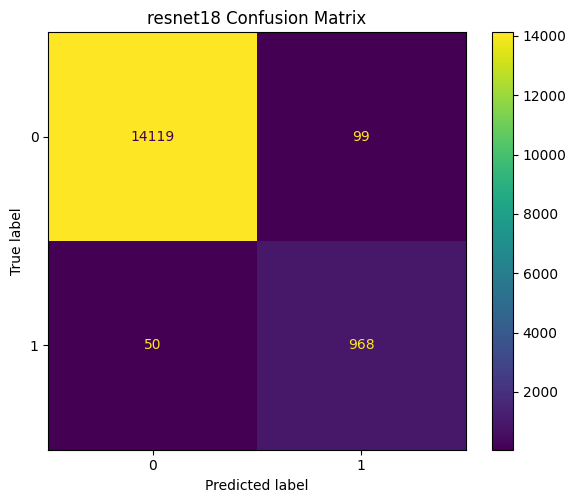

Saved confusion matrix: data\output\training\plots\resnet18_confusion_matrix.png


In [47]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

labels = sorted(
    np.unique(
        np.concatenate([y_true, y_pred])
    )
)

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

confusion_matrix_path = (
    PLOTS_DIR / f"{MODEL_NAME}_confusion_matrix.png"
)

display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[str(label) for label in labels]
)

fig, ax = plt.subplots(figsize=(6, 5))

display.plot(
    ax=ax,
    values_format="d"
)

ax.set_title(
    f"{MODEL_NAME} Confusion Matrix"
)

fig.tight_layout()

fig.savefig(
    confusion_matrix_path,
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(
    f"Saved confusion matrix: "
    f"{confusion_matrix_path}"
)

In [49]:
import json

train_class_counts = (
    train_df["label"]
    .value_counts()
    .sort_index()
    .to_dict()
)


metrics = {
    "model": MODEL_NAME,
    "best_val_macro_f1": float(best_val_f1),

    "test_accuracy": float(test_accuracy),
    "test_macro_precision": float(test_precision),
    "test_macro_recall": float(test_recall),
    "test_macro_f1": float(test_f1),

    "train_samples": int(len(train_df)),
    "val_samples": int(len(val_df)),
    "test_samples": int(len(test_df)),

    "train_class_counts": {
        str(label): int(count)
        for label, count in train_class_counts.items()
    }
}


metrics_path = (
    OUTPUT_DIR / f"metrics_{MODEL_NAME}.json"
)


with open(metrics_path, "w") as file:
    json.dump(
        metrics,
        file,
        indent=2
    )


print("\nSaved outputs:")
print(f"Best checkpoint: {best_checkpoint_path}")
print(f"Confusion matrix: {confusion_matrix_path}")
print(f"Metrics: {metrics_path}")


Saved outputs:
Best checkpoint: data\output\training\checkpoints\resnet18_best.pt
Confusion matrix: data\output\training\plots\resnet18_confusion_matrix.png
Metrics: data\output\training\metrics_resnet18.json
